In [1]:
import corner
import matplotlib as mpl
import numpy as np
import os
import pandas as pd
import pickle
from sklearn.preprocessing import RobustScaler

def call_plotting_formatting():

    font = {'family' : 'sans-serif',
    'weight' : 'medium',
    'size'   : 15,
    'variant' : 'normal',
    'style' : 'normal',
    'stretch' : 'normal',
    }

    xtick = {'top' : True,
            'bottom' : True,
            'major.size' : 7,
            'minor.size' : 4,
            'major.width' : 0.5,
            'minor.width' : 0.35,
            'direction' : 'in',
            'minor.visible' : True,
            'color' : 'black',
            'labelcolor' : 'black'
            }

    ytick = {'left' : True,
            'right' : True,
            'major.size' : 7,
            'minor.size' : 4,
            'major.width' : 0.5,
            'minor.width' : 0.35,
            'direction' : 'in',
            'minor.visible' : True,
            'color' : 'black',
            'labelcolor' : 'black'
            }

    mpl.rcParams['savefig.format'] = 'pdf'
    mpl.rcParams['savefig.bbox'] = 'tight'
    mpl.rcParams['figure.figsize'] = (6.973848069738481, 4.310075139476229)
    mpl.rcParams['figure.subplot.hspace'] = 0.01

    mpl.rc('font', **font)
    mpl.rc('xtick', **xtick)
    mpl.rc('ytick', **ytick)
    mpl.rcParams['legend.fontsize'] = 18
    mpl.rcParams["font.sans-serif"] = ["DejaVu Serif"]
    mpl.rcParams['mathtext.fontset']='dejavuserif'
    mpl.rcParams["text.usetex"] = False

call_plotting_formatting()


def plot_stars_data(dfs: list, RANGE=None):

    # Initialize color list for the different dataframes
    colors = [mpl.cm.tab10(i/len(dfs)) for i in range(len(dfs))]

    for i, df in enumerate(dfs):

        if i==0:
            fig = corner.corner(df[features].values,
                                color=colors[i],
                                labels=["$E$", "$L$", "[Fe/H]", "[Mg/Fe]"],
                                bins=20,
                                plot_contours=True,
                                plot_datapoints=False,
                                fill_contours=True,
                                hist_kwargs={"density": True},
                                alpha=0.5,
                                range=RANGE,
                                label_kwargs={'fontsize': 18},
                                )
        else:
            corner.corner(df[features].values,
                            color=colors[i],
                            bins=20,
                            plot_contours=True,
                            plot_datapoints=False,
                            fill_contours=True,
                            hist_kwargs={"density": True},
                            alpha=0.5,
                            range=RANGE,
                            label_kwargs={'fontsize': 18},
                            fig=fig)
            
    return fig


features = ['E', 'L', 'FeH', 'MgFe']
parameters = ['infall_time','log_Mprog_stellar', 'log_Mprog', 'log_Mprog2host']

output_dir = '/mnt/aridata1/users/ariasant/MW-sbi/fishnet_results/coral/'

print(f"output_dir: {output_dir}", flush=True)

filename = f"Suite_"+"".join(features)

substructures = ['Arjuna','GES', 'Sagittarius', 'Helmi',
                 'Sequoia_K19','Sequoia_M19','Sequoia_N20','Iitoi', 'Thamnos',
                 'LMS', 'Heracles']

###########################################################################################
# Data preparation
###########################################################################################

# Load Milky Way (target) data
obs_data = pd.read_pickle("/mnt/aridata1/users/ariasant/MW-sbi/data/apogee_substructures_ds.pkl")
apogee_ds_satellites = pd.read_pickle("/mnt/aridata1/users/ariasant/MW-sbi/data/apogee_satellites_ds.pkl")
obs_data = pd.concat([obs_data, apogee_ds_satellites])
obs_data.dropna(subset=features, inplace=True)
obs_data = obs_data[(obs_data["E"]<0)&(obs_data["L"]>0)]
# Select accreted stars
obs_accreted = ((obs_data.AlFe<-0.07) & (obs_data.MgMn>=0.25)) | \
               ((obs_data.AlFe>=-0.07) & (obs_data.MgMn>=4.25*obs_data.AlFe+0.5475))
obs_accreted = np.logical_or.reduce([obs_accreted]+[obs_data[f"{substructure}_flag"]==1 
                                    for substructure in substructures])


# Load simulation (source) data
data_dir = "/mnt/aridata1/users/ariasant/auriga-sbi/data/with_satellites/"
sim_data = []

for file in os.listdir(data_dir):

    df = pd.read_pickle(f"{data_dir}{file}")
    df.rename(columns={"aFe":"MgFe"}, inplace=True)

    # Get rid of stars with numerical issues
    df = df[(df["E"]<0) & (df["L"]>0) & 
            (df["MgFe"]<0.5) & (df["MgFe"]>-0.5) &
            (df["FeH"]<1) & (df["FeH"]>-3)]

    sim_data.append(df)

sim_data = pd.concat(sim_data, ignore_index=True)


output_dir: /mnt/aridata1/users/ariasant/MW-sbi/fishnet_results/coral/


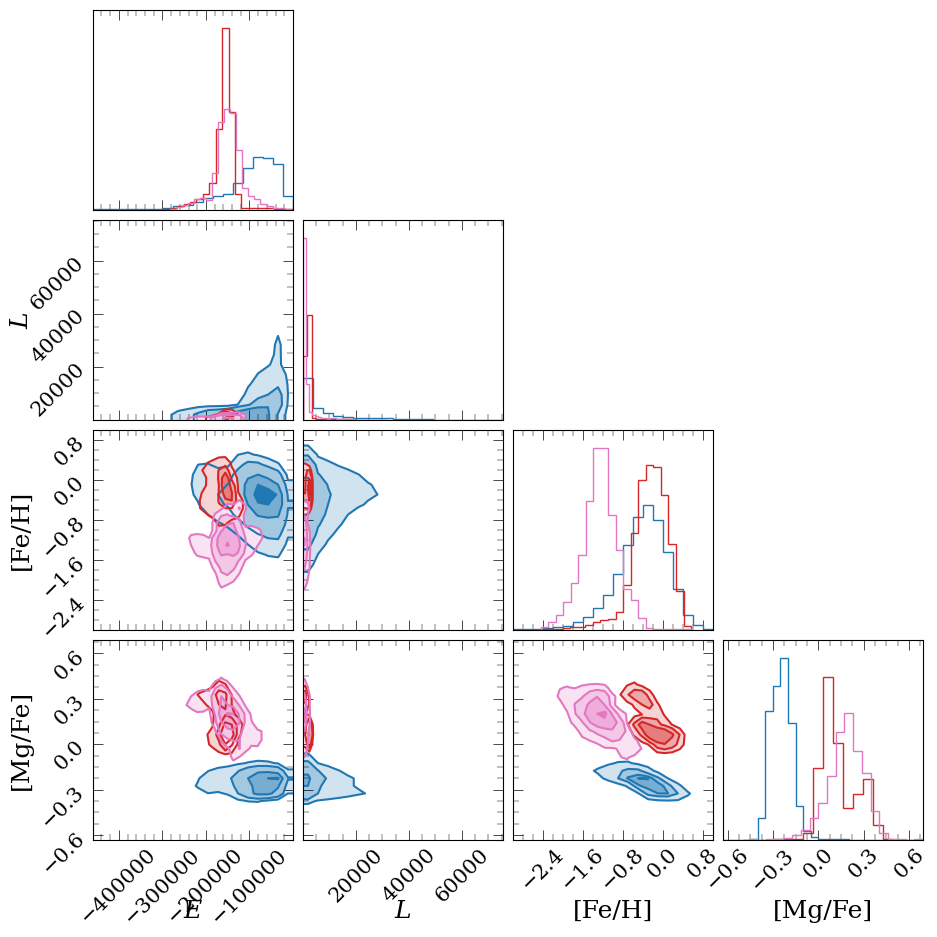

In [2]:
fig = plot_stars_data([sim_data, obs_data, obs_data[obs_accreted]])

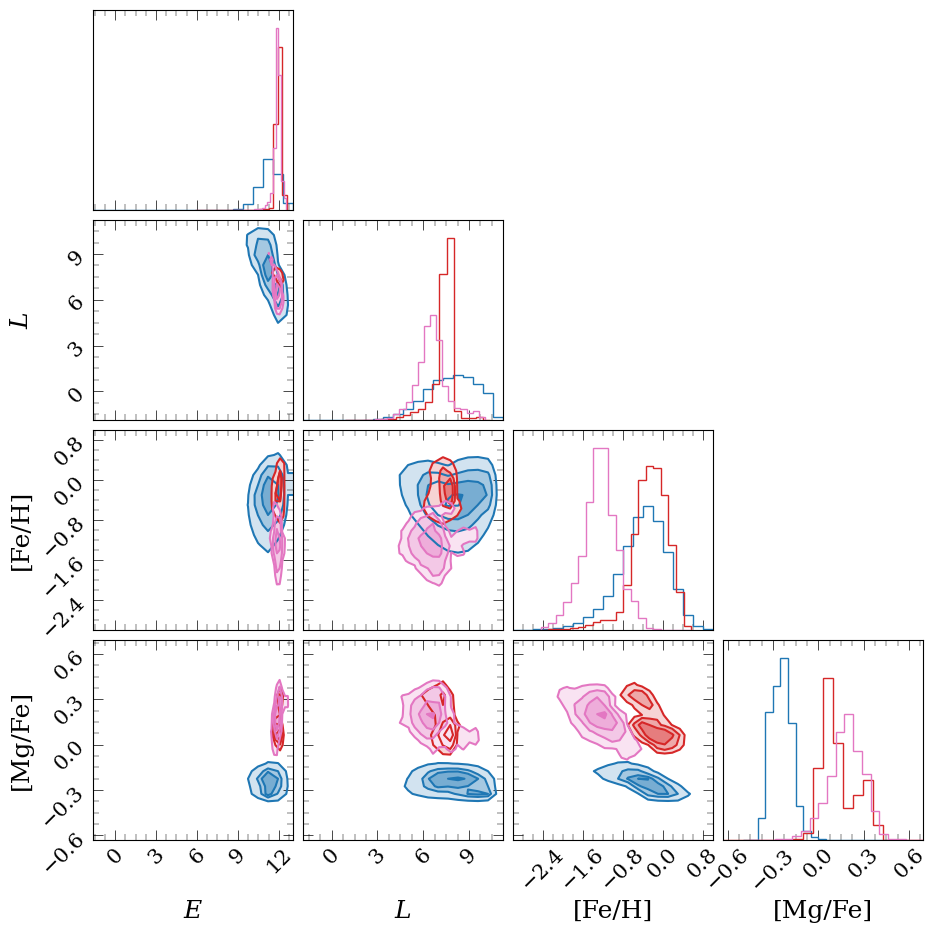

In [3]:
# Preprocess data
sim_data["E"] = np.log(-sim_data["E"].values)
sim_data["L"] = np.log(sim_data["L"].values)

obs_data["E"] = np.log(-obs_data["E"].values)
obs_data["L"] = np.log(obs_data["L"].values)

fig = plot_stars_data([sim_data, obs_data, obs_data[obs_accreted]])

In [ ]:
sim_data_shifted2 = sim_data.copy()
obs_data2 = obs_data.copy()
scaler = RobustScaler()

sim_data_shifted2[features] = scaler.fit_transform(sim_data_shifted2[features])
obs_data2[features] = scaler.transform(obs_data2[features])



shifts = [sim_data_shifted2[f].mean() - obs_data2[f].mean() for f in features]
stds = [max(sim_data_shifted2[f].std(), obs_data2[f].std()) for f in features]

def shift_props(group):


    mean_E = np.random.uniform(-self.self.self.shifts[0],shifts[0])
    std_E = np.random.uniform(0, 3*stds[0])

    mean_L = np.random.uniform(-shifts[1],shifts[1])
    std_L = np.random.uniform(0, 3*stds[1])

    mean_FeH = np.random.uniform(-2*shifts[2],shifts[2]/2)
    std_FeH = np.random.uniform(0, 3*stds[2])

    mean_MgFe = np.random.uniform(shifts[3]/2,2*shifts[3])
    std_MgFe = np.random.uniform(0, 3*stds[3])

    group["E"] -= np.random.normal(loc=mean_E, scale=std_E, size=group.shape[0])
    group["L"] -= np.random.normal(loc=mean_L, scale=std_L, size=group.shape[0])
    group["FeH"] -= np.random.normal(loc=mean_FeH, scale=std_FeH, size=group.shape[0])
    group["MgFe"] -= np.random.normal(loc=mean_MgFe, scale=std_MgFe, size=group.shape[0])

    return group


sim_data_shifted2 = sim_data_shifted2.groupby("progID").apply(shift_props)

/tmp/ipykernel_2893555/3415054682.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sim_data_shifted2 = sim_data_shifted2.groupby("progID").apply(shift_props)


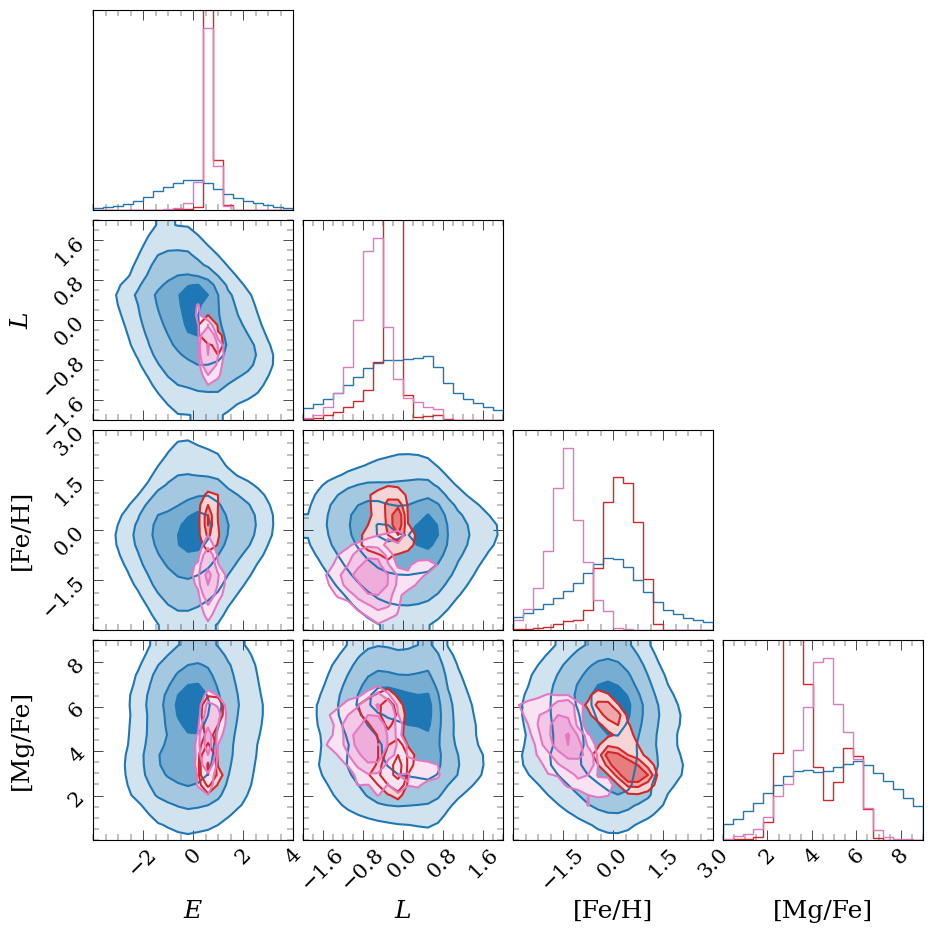

In [12]:
fig = plot_stars_data([sim_data_shifted2, obs_data2, obs_data2[obs_accreted]], RANGE=[(-4,4),(-2,2),(-3,3),(0,9)])

0.29455446038957445

In [ ]:
import corner
import math
import numpy as np
import optuna
import pandas as pd
import pickle
import torch

import sys
sys.path.append("/mnt/aridata1/users/ariasant/MW-sbi/")
import fishnets

In [9]:
model_dir = "/mnt/aridata1/users/ariasant/MW-sbi/fishnet_results/coral/"
output_dir = "/mnt/aridata1/users/ariasant/MW-sbi/fishnet_results/coral/"

features=["E","L","FeH","MgFe"]

# Posterior model
posterior = pickle.load(open(f"{model_dir}Suite_ELFeHMgFe.pkl","rb"))

# Data processing tools
theta_scaler = pickle.load(open(f"{model_dir}data/theta_scaler_Suite_ELFeHMgFe.pkl","rb")) # progenitor properties scaler

plot_labels=['$\\tau \, [\mathrm{Gyr}]$',
             'log($M_{*}/M_{\odot}$)',
             'log($M/M_{\odot}$)', 
             'MMR (log)']

study = optuna.load_study(study_name="ltu_ili_npe_tarp_study",
                            storage="sqlite:////mnt/aridata1/users/ariasant/MW-sbi/optuna_study/hyperparameters_search.db")
params = study.best_trials[0].params
fishnet_params = {
        "n_hidden_layers": params["hidden_layers_fish"],
        "n_nodes_per_layer": params["nodes_per_layer_fish"]
    }

# Compression model
compression_model = fishnets.FISHNET(n_params=4,
                                     n_d=100,
                                     n_features=len(features),
                                     **fishnet_params)
# Load trained weights
w = pickle.load(open(f"{output_dir}Suite_ELFeHMgFe_compression_model_w.pkl","rb")) 
compression_model.w = w

# Load pre-processed apogee sample
df = pd.read_pickle(f"{model_dir}data/apogee_ds_processed_Suite_ELFeHMgFe.pkl")

df_unprocessed = pd.read_pickle("/mnt/aridata1/users/ariasant/MW-sbi/data/apogee_substructures_ds.pkl")

substructures = ['Arjuna', 'GES', 'Sagittarius', 'Helmi',
       'Sequoia_K19','Sequoia_M19','Sequoia_N20','Iitoi', 'Thamnos',
       'LMS', 'Heracles', 'Sequoia_ALL']

In [23]:
substructure="Helmi"
if substructure=="GES":
    IDS = df_unprocessed.loc[(df_unprocessed[substructure+"_flag"]==1) & (df_unprocessed["FeH"]<-1), "APOGEE_ID"].values
else:
    IDS = df_unprocessed.loc[df_unprocessed[substructure+"_flag"]==1, "APOGEE_ID"].values
df_sub = df[(df["APOGEE_ID"].isin(IDS)) & (df[substructure+"_flag"]==1)].copy()
print(f"N stars in {substructure}: {df_sub.shape[0]:,}", flush=True)

N stars in Helmi: 101


In [24]:
data = df_sub[features].values
n_samples = math.ceil(len(data)/100)*10
data_samples = [data[np.random.randint(0,len(data),size=100)] for i in range(n_samples)]

posterior_samples = []
for data_sample in data_samples:

    # Compress data features
    data_sample, _, __ = compression_model(data_sample)

    # Decide how many samples to get from the posterior
    n_samples = 100

    # Get posterior samples
    theta_samples = posterior.sample((n_samples,), 
                            torch.Tensor(data_sample).to(device="cuda"))

    theta_samples = theta_samples.cpu().numpy()
    theta_samples = theta_scaler.inverse_transform(theta_samples)

    posterior_samples.append(theta_samples)

# Concatenate all posterior samples
posterior_samples = np.concatenate(posterior_samples, axis=0)

INFO:root:Sampling models with [21, 35, 46] samples each.
Drawing 46 posterior samples: 100%|██████████| 46/46 [00:00<00:00, 1752.91it/s]
INFO:root:Sampling models with [21, 35, 46] samples each.
Drawing 46 posterior samples: 100%|██████████| 46/46 [00:00<00:00, 1721.72it/s]
INFO:root:Sampling models with [21, 35, 46] samples each.
Drawing 46 posterior samples: 100%|██████████| 46/46 [00:00<00:00, 1748.43it/s]
INFO:root:Sampling models with [21, 35, 46] samples each.
Drawing 46 posterior samples: 100%|██████████| 46/46 [00:00<00:00, 1748.56it/s]
INFO:root:Sampling models with [21, 35, 46] samples each.
Drawing 46 posterior samples: 100%|██████████| 46/46 [00:00<00:00, 1728.71it/s]
INFO:root:Sampling models with [21, 35, 46] samples each.
Drawing 46 posterior samples: 100%|██████████| 46/46 [00:00<00:00, 1724.82it/s]
INFO:root:Sampling models with [21, 35, 46] samples each.
Drawing 46 posterior samples: 100%|██████████| 46/46 [00:00<00:00, 1748.20it/s]
INFO:root:Sampling models with [21

Quantiles:
[(0.16, np.float64(9.57577823638916)), (0.5, np.float64(10.03025484085083)), (0.84, np.float64(10.679386749267579))]
Quantiles:
[(0.16, np.float64(8.48400447845459)), (0.5, np.float64(8.643356323242188)), (0.84, np.float64(8.790227699279786))]
Quantiles:
[(0.16, np.float64(10.12076774597168)), (0.5, np.float64(10.34414529800415)), (0.84, np.float64(10.575768241882324))]
Quantiles:
[(0.16, np.float64(-0.9439056468009949)), (0.5, np.float64(-0.8281711935997009)), (0.84, np.float64(-0.6583008861541748))]


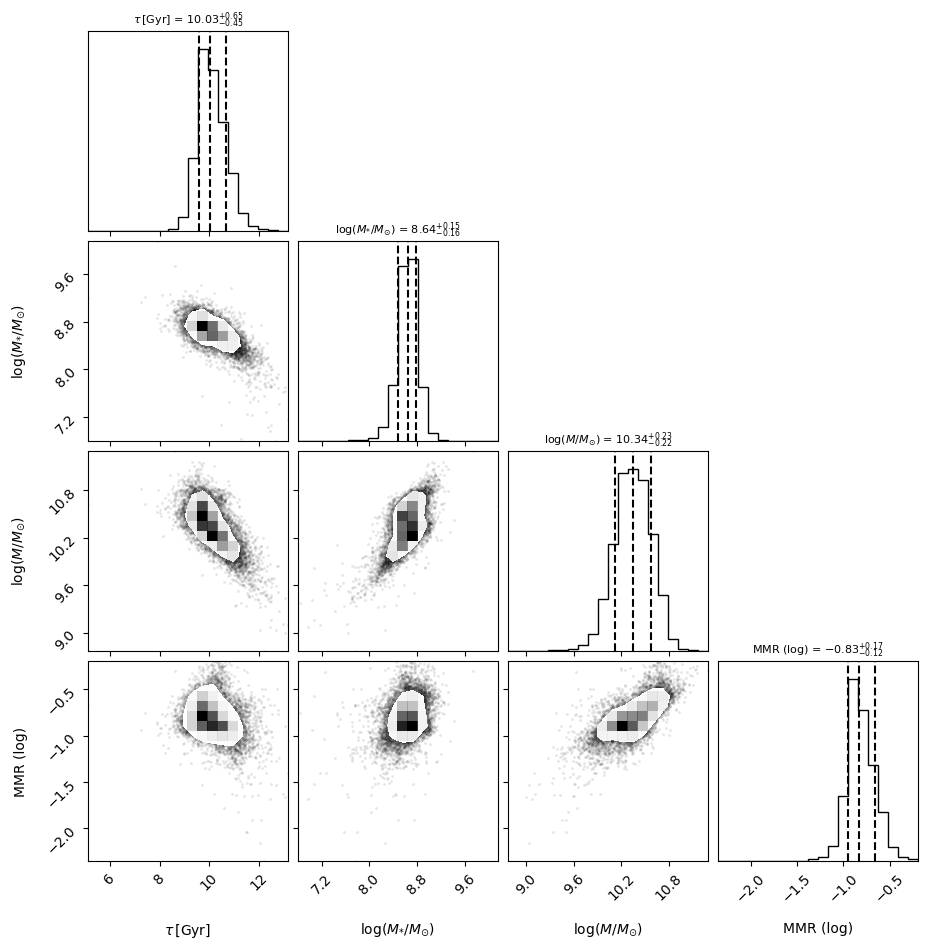

In [17]:
fig = corner.corner(posterior_samples, 
                        bins=20, 
                        labels=plot_labels,
                        quantiles=[.16,.50,.84],
                        plot_contours=False,
                        show_titles=True,
                        title_kwargs={'fontsize':8},
                        verbose=True)

In [1]:
from ili.dataloaders import TorchLoader
from ili.utils import Uniform, load_nde_lampe
from ili.inference import InferenceRunner
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import math
import numpy as np
import optuna
import os
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
import time
import torch

import sys
sys.path.append("/mnt/aridata1/users/ariasant/MW-sbi/")
import fishnets
import optuna_opt
import sbi_results
import sbi_training


# Load training and test data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Set numpy random key
rng = np.random.default_rng(17)



features = ["E","L","FeH","MgFe"]
parameters = ['infall_time','log_Mprog_stellar', 'log_Mprog', 'log_Mprog2host']
filename = f"Suite_"+"".join(features)

output_dir = '/mnt/aridata1/users/ariasant/MW-sbi/fishnet_results/shifts_marg/'

sim_data = pd.read_pickle(f"{output_dir}/data/sim_ds_processed_{filename}.pkl")
obs_data = pd.read_pickle(f"{output_dir}/data/apogee_ds_processed_{filename}.pkl")
scaler_params = pickle.load(open(f"{output_dir}/data/theta_scaler_Suite_ELFeHMgFe.pkl","rb")) 

shifts = [sim_data[f].mean() - obs_data[f].mean() for f in features]
stds = [max(sim_data[f].std(), obs_data[f].std()) for f in features]

print(f"N progID: {len(sim_data['progID'].unique())}", flush=True)


data_file = f"{output_dir}/data/training_data.npz"

if os.path.exists(data_file):
    print("Loading pre-saved training data...", flush=True)
    data = np.load(data_file)
    X_train = data['X_train']
    Y_train = data['Y_train']
else:
    print("Saving training data for future use...", flush=True)
    # Create datasets for training 
    X_train, Y_train = [], []

    for progID in sim_data["progID"].unique():
        # Get the data for the current progenitor
        prog_data = sim_data[sim_data["progID"]==progID]
        if len(prog_data) < 100:
            continue
        # Sample the data n times
        n = min(100, math.ceil(len(prog_data)//100))
        for i in range(n):
            idx_sample = np.random.randint(0, len(prog_data), size=100)

            X_train.append(prog_data[features].values[idx_sample])
            Y_train.append(prog_data[parameters].values[idx_sample][0])
    X_train = np.stack(X_train)
    Y_train = np.stack(Y_train)
    np.savez(data_file, X_train=X_train, Y_train=Y_train)


# Split the data into training and test(validation) sets
X_train, X_test, Y_train, Y_test = train_test_split(X_train, Y_train, test_size=0.1)

test_dictionary = {"X": X_test,
                   "Y": Y_test,
                   "ID": [f"{i:05}" for i in range(len(Y_test))]}

print(f"X_train shape: {X_train.shape}", flush=True)
print(f"Y_train shape: {Y_train.shape}", flush=True)
print(f"X_test shape: {X_test.shape}", flush=True)
print(f"Y_test shape: {Y_test.shape}", flush=True)

/mnt/aridata1/users/ariasant/environments/fish/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:2025-07-21 15:35:02,693:jax._src.xla_bridge:752: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


[CudaDevice(id=0)]
Device: cuda
N progID: 576
Loading pre-saved training data...
X_train shape: (18389, 100, 4)
Y_train shape: (18389, 4)
X_test shape: (2044, 100, 4)
Y_test shape: (2044, 4)


In [9]:
from ili.inference import LampeRunner

In [ ]:
import json
import yaml
import time
import logging
import pickle
from copy import deepcopy
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import lampe
from pathlib import Path
from typing import Dict, List, Callable, Optional
from torch.distributions import Distribution
from ili.dataloaders import _BaseLoader
from ili.utils import load_from_config, LampeEnsemble, load_nde_lampe

class my_runner(LampeRunner):

    def __init__(self, compression_model, noise_list, **kwargs):

        super().__init__(**kwargs)
        self.noise_list = noise_list
        self.compression_model = compression_model


    def _train_epoch(self, model, train_loader, val_loader, stepper):
        """Train a single epoch of a neural network model."""
        model.train()

        loss_train, count = [], 0
        for x, theta in train_loader:
            # Add noise to x
            idx = np.random.randint(len(self.noise_list))
            x += self.noise_list[idx]
            # Use compression model
            x,_,__ = self.compression_model(x)
            x = torch.from_numpy(x).float()
            x, theta = x.to(self.device), theta.to(self.device)
            loss_train.append(
                stepper(self._loss(model, theta, x)) * len(theta))
            count += len(theta)
        loss_train = torch.stack(loss_train).sum().item()/count

        model.eval()
        with torch.no_grad():
            loss_val, count = [], 0
            for x, theta in val_loader:
                # Add noise to x
                idx = np.random.randint(len(self.noise_list))
                x += self.noise_list[idx]
                # Use compression model
                x,_,__ = self.compression_model(x)
                x = torch.from_numpy(x).float()
                x, theta = x.to(self.device), theta.to(self.device)
                loss_val.append(self._loss(model, theta, x) * len(theta))
                count += len(theta)
            loss_val = torch.stack(loss_val).sum().item()/count
        return loss_train, loss_val




In [21]:
study_path = f"{output_dir}optuna_study/hyperparameters_search.db"
if os.path.exists(study_path):
    # Load exististing study
    study = optuna.load_study(study_name="ltu_ili_npe_tarp_study",
                              storage=f"sqlite:///{study_path}")
    params = study.best_trials[0].params

fishnet_params = {
        "n_hidden_layers": params["hidden_layers_fish"],
        "n_nodes_per_layer": params["nodes_per_layer_fish"]
    }
npe_params = {
    "model": params["model"],
    "hidden_features": params["hidden_features"],
    "num_transforms": params["num_transforms"]
}

# Learn data compression model with fishnet
compression_model = fishnets.FISHNET(n_params=4,
                                     n_d=100,
                                     n_features=len(features),
                                     **fishnet_params)

compression_model_weights = pickle.load(open(f"{output_dir}{filename}_compression_model_w.pkl", "rb"))
compression_model.w = compression_model_weights

##
"""prior = Uniform(low=scaler_params.transform(np.array([0,6,8,-3])[None,:] )[0],
                high=scaler_params.transform(np.array([14,11,12,0])[None,:] )[0],
                device=device)

posterior_model = pickle.load(open(f'{output_dir}{filename}.pkl', 'rb'))
"""

"prior = Uniform(low=scaler_params.transform(np.array([0,6,8,-3])[None,:] )[0],\n                high=scaler_params.transform(np.array([14,11,12,0])[None,:] )[0],\n                device=device)\n\nposterior_model = pickle.load(open(f'{output_dir}{filename}.pkl', 'rb'))\n"

In [24]:
# Compress data

# Define prior
prior = Uniform(low=scaler_params.transform(np.array([0,6,8,-3])[None,:] )[0],
                high=scaler_params.transform(np.array([14,11,12,0])[None,:] )[0],
                device=device)


train_args = dict(
    training_batch_size=256,
    learning_rate=1e-4,
)

# Define NPE model
nets = [load_nde_lampe(**npe_params,
        x_normalize=False,
        device=device,
) for i in range(3)]

runner = my_runner(compression_model=compression_model,
                   shifts=shifts,
                   stds=stds,
                   prior=prior,
                   nets=nets,
                   device=device,
                   engine='NPE',
                   train_args=train_args)


"""runner = InferenceRunner.load(
    backend="lampe",
    engine="NPE",
    prior=prior,
    nets=nets,
    device=device,
    train_args=train_args,
)"""



# Train NPE
# Use fixed train/test split defined outside objective
train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(Y_train).float()),
    batch_size=256, shuffle=True
)
val_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.from_numpy(X_test).float(), torch.from_numpy(Y_test).float()),
    batch_size=256, shuffle=False
)
loader = TorchLoader(train_loader=train_loader, val_loader=val_loader)


posterior_model, summaries = runner(loader=loader)

# Plot train/validation loss
fig, ax = plt.subplots(1, 1, figsize=(6,4))
c = list(mcolors.TABLEAU_COLORS)
for i, m in enumerate(summaries):
    ax.plot(m['training_log_probs'], ls='-', label=f"{i}_train", c=c[i])
    ax.plot(m['validation_log_probs'], ls='--', label=f"{i}_val", c=c[i])
ax.set_xlim(0)
ax.set_xlabel('Epoch')
ax.set_ylabel('Log probability')
ax.set_ylim([-10,10])
ax.legend()

INFO:root:MODEL INFERENCE CLASS: NPE


ValueError: Embedding network must return a vector.

INFO:root:Sampling models with [481, 402, 118] samples each.
Drawing 481 posterior samples: 100%|██████████| 481/481 [00:00<00:00, 16437.53it/s]
Drawing 402 posterior samples: 803it [00:00, 15074.05it/s]            
Drawing 118 posterior samples: 235it [00:00, 4427.45it/s]             
INFO:root:Sampling models with [481, 402, 118] samples each.
Drawing 481 posterior samples: 100%|██████████| 481/481 [00:00<00:00, 18046.23it/s]
Drawing 402 posterior samples: 803it [00:00, 15207.11it/s]            
Drawing 118 posterior samples: 100%|██████████| 118/118 [00:00<00:00, 4437.58it/s]
INFO:root:Sampling models with [481, 402, 118] samples each.
Drawing 118 posterior samples: 100%|██████████| 118/118 [00:00<00:00, 4486.82it/s]
INFO:root:Sampling models with [481, 402, 118] samples each.
Drawing 481 posterior samples: 100%|██████████| 481/481 [00:00<00:00, 17986.70it/s]
Drawing 402 posterior samples: 803it [00:00, 15067.51it/s]            
Drawing 118 posterior samples: 100%|██████████| 118/11

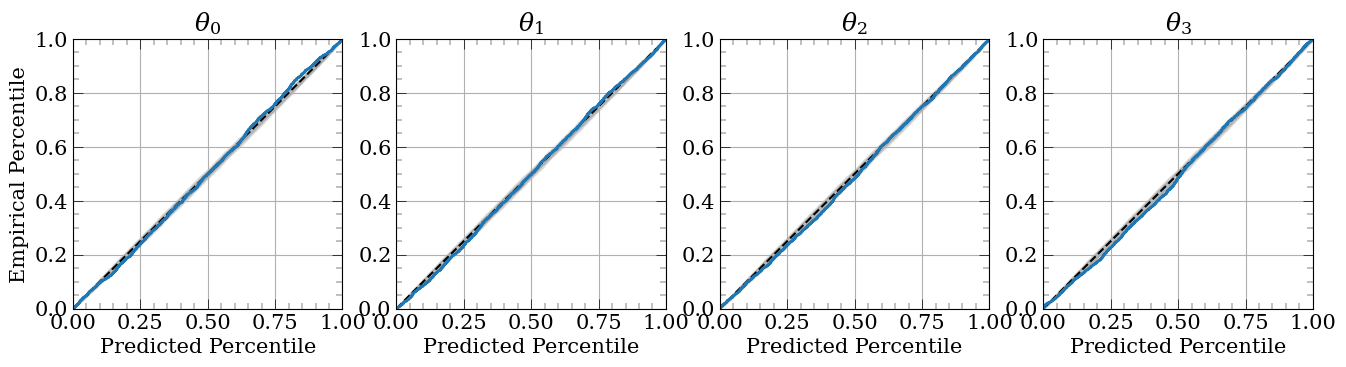

INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode


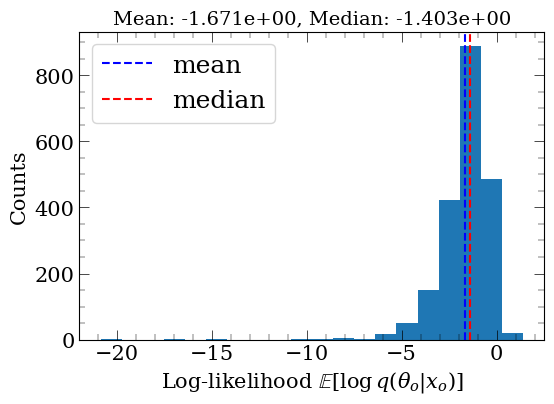

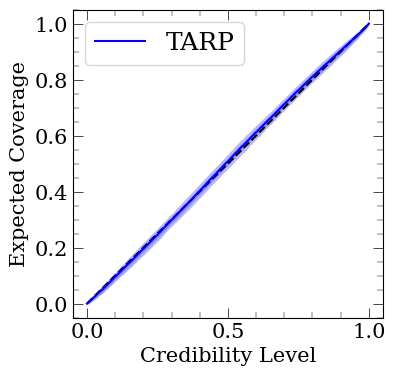

In [30]:
# Sample parameters for test galaxy
samples = sbi_training.validation(posterior_ensemble=posterior_model,
                              test_dictionary=test_dictionary,
                              filename=filename,
                              output_dir=output_dir)
    
# Scale back the merger parameters into the original representation
for progID in samples.keys():
    theta_pred, log_p, theta_fid = samples[progID]
    samples[progID] = (scaler_params.inverse_transform(theta_pred),
                        log_p,
                        scaler_params.inverse_transform(theta_fid[None,:])[0])


pickle.dump(samples, 
            open(f'{output_dir}{filename}_test_samples.pkl', 'wb'))

431


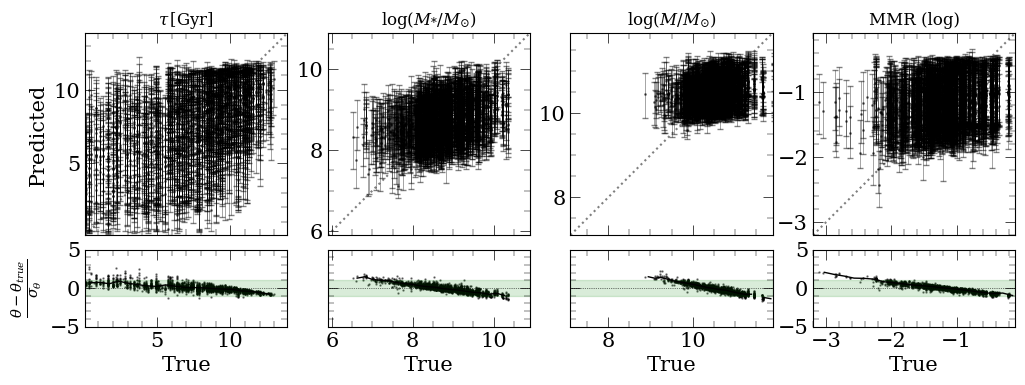

In [31]:
filename = "Suite_"+"".join(features)+"".join(parameters)
# Make plot of cross-validated parameters inference
plot_labels=['$\\tau \, [\mathrm{Gyr}]$',
             'log($M_{*}/M_{\odot}$)',
             'log($M/M_{\odot}$)', 
             'MMR (log)']
plot_ranges=[[0.1,13.9],[5.9,10.9],[7.1,11.9],[-3.2,-0.1]]

sbi_results.cross_validation_plot(samples=[samples],
                                  percentile_range=[16,84],
                                  plot_labels=plot_labels,
                                  plot_ranges=plot_ranges,
                                  filename=f'{output_dir}cross_validation_1684_{filename}.png')

# Save table with quantitative results 
sbi_results.rms_table_per_galaxy(samples={"SUITE":samples},
                                 parameters=parameters,
                                 filename=f'{output_dir}rms_table_{filename}.csv')

sbi_results.count_predictions_within_range(samples={"SUITE":samples},
                                           parameters=parameters,
                                           percentile_range=[16,84],
                                           filename=f'{output_dir}range_table_{filename}_1684.csv')



In [32]:
import corner
import math
import numpy as np
import optuna
import pandas as pd
import pickle
import torch

import sys
sys.path.append("/mnt/aridata1/users/ariasant/MW-sbi/")
import fishnets

model_dir = '/mnt/aridata1/users/ariasant/MW-sbi/fishnet_results/shifts_marg/'
output_dir = '/mnt/aridata1/users/ariasant/MW-sbi/fishnet_results/shifts_marg/'
study_path = f"{output_dir}optuna_study/hyperparameters_search.db"

features=["E","L","FeH","MgFe"]

# Posterior model
posterior = posterior_model

# Data processing tools
theta_scaler = pickle.load(open(f"{model_dir}data/theta_scaler_Suite_ELFeHMgFe.pkl","rb")) # progenitor properties scaler

plot_labels=['$\\tau \, [\mathrm{Gyr}]$',
             'log($M_{*}/M_{\odot}$)',
             'log($M/M_{\odot}$)', 
             'MMR (log)']

# Load the hyperaparameters for the compression model
# Load exististing study
study = optuna.load_study(study_name="ltu_ili_npe_tarp_study",
                              storage=f"sqlite:///{study_path}")
params = study.best_trials[0].params
fishnet_params = {
        "n_hidden_layers": params["hidden_layers_fish"],
        "n_nodes_per_layer": params["nodes_per_layer_fish"]
    }

# Compression model
compression_model = fishnets.FISHNET(n_params=4,
                                     n_d=100,
                                     n_features=len(features),
                                     **fishnet_params)
# Load trained weights
w = pickle.load(open(f"{output_dir}Suite_ELFeHMgFe_compression_model_w.pkl","rb")) 
compression_model.w = w

# Load pre-processed apogee sample
df = pd.read_pickle(f"{model_dir}data/apogee_ds_processed_Suite_ELFeHMgFe.pkl")

substructures = ['Arjuna', 'GES', 'Sagittarius', 'Helmi',
       'Sequoia_K19','Sequoia_M19','Sequoia_N20','Iitoi', 'Thamnos',
       'LMS', 'Heracles', 'Sequoia_ALL']

for substructure in substructures:
    
    if substructure!="Heracles":
        df_sub = df[df[substructure+"_flag"]==1]
        # Remove stars from the GES sample that are too close to the Galaxy centre
        #df_sub = df_sub[(df_sub.GAL_LAT**2>20**2) & (df_sub.GAL_LON**2>20**2)]

    if substructure=="GES":
        df_sub = df[df[substructure+"_flag"]==1]
        # Improve purity of GES sample
        #df_sub = df_sub[df_sub["FeH"]<-0.6]
        print(f"N stars in {substructure}: {df_sub.shape[0]:,}", flush=True)

    elif substructure=="Sagittarius":
        # Consider the stars that match with the selection of Hernquist
        #satellites_data = pd.read_csv("/mnt/aridata1/users/ariasant/MW-sbi/data/member_list_fe_mg.txt")
        #SGR_star_IDs = satellites_data[satellites_data["System"]=="Sgr"]["APOGEE_ID"].values
        #df_sub = df[df["APOGEE_ID"].isin(SGR_star_IDs)]
        df_sub = df[df[substructure+"_flag"]==1]
        print(f"N stars in {substructure}: {df_sub.shape[0]:,}", flush=True)

    elif substructure=="Sequoia_ALL":
        # Consider all the sequoia samples together
        df_sub = df[(df["Sequoia_M19_flag"]==1) | 
                    (df["Sequoia_K19_flag"]==1) | 
                    (df["Sequoia_N20_flag"]==1)]
        print(f"N stars in {substructure}: {df_sub.shape[0]:,}", flush=True)

    
    data = df_sub[features].values

    # Select 10 samples of 100 stars each from data
    # get how many times you can sample from the progenitor
    n_samples = math.ceil(len(data)/100)*10
    data_samples = [data[np.random.randint(0,len(data),size=100)] for i in range(n_samples)]

    # Sample the posterior of the progenitor properties as conditioned by each data sample
    posterior_samples = []
    for data_sample in data_samples:

        # Compress data features
        data_sample, _, __ = compression_model(data_sample)

        # Decide how many samples to get from the posterior
        n_samples = 100

        # Get posterior samples
        theta_samples = posterior.sample((n_samples,), 
                                torch.Tensor(data_sample).to(device="cuda"))

        theta_samples = theta_samples.cpu().numpy()
        theta_samples = theta_scaler.inverse_transform(theta_samples)

        posterior_samples.append(theta_samples)

    # Concatenate all posterior samples
    posterior_samples = np.concatenate(posterior_samples, axis=0)
    
    # Save posterior samples
    pickle.dump(posterior_samples, open(f"{output_dir}{substructure}.pkl","wb"))
    
    # Plot posterior samples
    fig = corner.corner(posterior_samples, 
                        bins=20, 
                        labels=plot_labels,
                        quantiles=[.16,.50,.84],
                        plot_contours=False,
                        show_titles=True,
                        title_kwargs={'fontsize':8},
                        verbose=True)
    fig.savefig(f"{output_dir}{substructure}.pdf",dpi=400)
    fig.clf()



INFO:root:Sampling models with [49, 41, 12] samples each.
Drawing 12 posterior samples: 100%|██████████| 12/12 [00:00<00:00, 454.06it/s]
INFO:root:Sampling models with [49, 41, 12] samples each.
Drawing 12 posterior samples: 100%|██████████| 12/12 [00:00<00:00, 458.76it/s]
INFO:root:Sampling models with [49, 41, 12] samples each.
Drawing 12 posterior samples: 100%|██████████| 12/12 [00:00<00:00, 459.76it/s]
INFO:root:Sampling models with [49, 41, 12] samples each.
Drawing 12 posterior samples: 100%|██████████| 12/12 [00:00<00:00, 458.17it/s]
INFO:root:Sampling models with [49, 41, 12] samples each.
Drawing 12 posterior samples: 100%|██████████| 12/12 [00:00<00:00, 456.21it/s]
INFO:root:Sampling models with [49, 41, 12] samples each.
Drawing 12 posterior samples: 100%|██████████| 12/12 [00:00<00:00, 456.90it/s]
INFO:root:Sampling models with [49, 41, 12] samples each.
Drawing 12 posterior samples: 100%|██████████| 12/12 [00:00<00:00, 458.13it/s]
INFO:root:Sampling models with [49, 41, 1

Quantiles:
[(0.16, np.float64(7.412904205322266)), (0.5, np.float64(9.96493148803711)), (0.84, np.float64(11.449037170410156))]
Quantiles:
[(0.16, np.float64(7.549977798461914)), (0.5, np.float64(8.314452171325684)), (0.84, np.float64(8.865004386901855))]
Quantiles:
[(0.16, np.float64(9.797313919067383)), (0.5, np.float64(10.246092796325684)), (0.84, np.float64(10.650716094970702))]
Quantiles:
[(0.16, np.float64(-1.7371036720275879)), (0.5, np.float64(-1.2375483512878418)), (0.84, np.float64(-0.7673876309394837))]
N stars in GES: 2,370


INFO:root:Sampling models with [49, 41, 12] samples each.
Drawing 12 posterior samples: 100%|██████████| 12/12 [00:00<00:00, 458.93it/s]
INFO:root:Sampling models with [49, 41, 12] samples each.
Drawing 12 posterior samples: 100%|██████████| 12/12 [00:00<00:00, 459.31it/s]
INFO:root:Sampling models with [49, 41, 12] samples each.
Drawing 12 posterior samples: 100%|██████████| 12/12 [00:00<00:00, 455.74it/s]
INFO:root:Sampling models with [49, 41, 12] samples each.
Drawing 12 posterior samples: 100%|██████████| 12/12 [00:00<00:00, 458.04it/s]
INFO:root:Sampling models with [49, 41, 12] samples each.
Drawing 49 posterior samples: 97it [00:00, 1820.74it/s]             
Drawing 12 posterior samples: 100%|██████████| 12/12 [00:00<00:00, 458.61it/s]
INFO:root:Sampling models with [49, 41, 12] samples each.
Drawing 12 posterior samples: 100%|██████████| 12/12 [00:00<00:00, 455.85it/s]
INFO:root:Sampling models with [49, 41, 12] samples each.
Drawing 12 posterior samples: 100%|██████████| 12/1

Quantiles:
[(0.16, np.float64(7.818738651275635)), (0.5, np.float64(9.779901504516602)), (0.84, np.float64(11.176181144714356))]
Quantiles:
[(0.16, np.float64(8.170074005126953)), (0.5, np.float64(8.790349960327148)), (0.84, np.float64(9.435551376342774))]
Quantiles:
[(0.16, np.float64(9.99193489074707)), (0.5, np.float64(10.484943866729736)), (0.84, np.float64(11.041925354003906))]
Quantiles:
[(0.16, np.float64(-1.4819502687454222)), (0.5, np.float64(-1.0012462735176086)), (0.84, np.float64(-0.5431097865104675))]
N stars in Sagittarius: 116


INFO:root:Sampling models with [49, 41, 12] samples each.
Drawing 12 posterior samples: 100%|██████████| 12/12 [00:00<00:00, 455.32it/s]
INFO:root:Sampling models with [49, 41, 12] samples each.
Drawing 12 posterior samples: 100%|██████████| 12/12 [00:00<00:00, 457.20it/s]
INFO:root:Sampling models with [49, 41, 12] samples each.
Drawing 12 posterior samples: 100%|██████████| 12/12 [00:00<00:00, 459.06it/s]
INFO:root:Sampling models with [49, 41, 12] samples each.
Drawing 12 posterior samples: 100%|██████████| 12/12 [00:00<00:00, 455.33it/s]
INFO:root:Sampling models with [49, 41, 12] samples each.
Drawing 12 posterior samples: 100%|██████████| 12/12 [00:00<00:00, 454.36it/s]
INFO:root:Sampling models with [49, 41, 12] samples each.
Drawing 12 posterior samples: 100%|██████████| 12/12 [00:00<00:00, 458.95it/s]
INFO:root:Sampling models with [49, 41, 12] samples each.
Drawing 12 posterior samples: 100%|██████████| 12/12 [00:00<00:00, 455.14it/s]
INFO:root:Sampling models with [49, 41, 1

...

<Figure size 970x970 with 0 Axes>

<Figure size 970x970 with 0 Axes>

<Figure size 970x970 with 0 Axes>

<Figure size 970x970 with 0 Axes>

<Figure size 970x970 with 0 Axes>

In [ ]:
import pymc as pm
features = ["E","L","FeH","MgFe"]

def generate_mean_cov_model(features, 
                            n_stars_per_prog,
                            n_progenitors):

    n_features = len(features)
    coords = {"features": features, 
              "features_bis": features, 
              "star_id": np.arange(n_stars_per_prog),
              "prog_id": np.arange(n_progenitors)}

    bounds = {"E": (-shifts[0], shifts[0]),
            "L": (-shifts[1], shifts[1]),
            "FeH": (-2*shifts[2], 0.5*shifts[2]),
            "MgFe": (0.5*shifts[3], 2*shifts[3])}
    with pm.Model(coords=coords) as model:
        chol, corr, stds = pm.LKJCholeskyCov(
            "chol", 
            n=n_features, 
            eta=2.0, 
            sd_dist=pm.Exponential.dist(1.0, shape=n_features)
        )

        mu_components = pm.math.stack([pm.Uniform(f"mu_{f}", 
                                                lower=bounds[f][0],
                                                upper=bounds[f][1]) for f in features])
        mu = pm.Deterministic("shifts", mu_components, dims="features")

        noise_stars_in_single_prog = pm.MvNormal("noise", 
                                                  mu, 
                                                  chol=chol, 
                                                  dims=("prog_id", "star_id", "features"))
        
        return model
        
def sample_noise_training(model, 
                          n_epochs,
                          random_seed):

    with model:
        prior_samples = pm.sample_prior_predictive(samples=n_epochs,
                                                   random_seed=random_seed)
        
    return jnp.array(prior_samples.prior["noise"].values[0])



with model:
    # `pm.sample_prior_predictive` draws samples from the prior distributions of your model's variables.
    # By default, it returns an ArviZ InferenceData object.
    prior_samples = pm.sample_prior_predictive(samples=23, random_seed=42)

sampled_mus = jnp.array(prior_samples.prior["shifts"].values)
sampled_covs = jnp.array(prior_samples.prior["cov"].values)

generated_noise = jax.random.multivariate_normal(
        key_noise,
        mean=sampled_mus,
        cov=sampled_covs,
        shape=(100,23) # Generates (total_samples_in_X, num_dimensions) noise
    )

with pm.Model() as noise_model:

    # Sample noise for data points from multivariate normal distribution
    mu = pm.Uniform("mean_shifts", lower=0, upper=1, dims=4)
    chol, corr, stds = pm.LKJCholeskyCov(
        "chol", n=2, eta=2.0, sd_dist=pm.Exponential.dist(1.0, shape=2)
    )
    cov = pm.Deterministic("cov", chol.dot(chol.T), dims=("axis", "axis_bis"))
    obs = pm.MvNormal("obs", mu, chol=chol, dims=("obs_id", "axis"))



In [ ]:
def add_correlated_noise(X,
                         noise_chol_factor,
                         key_noise):
    """
    Adds correlated multivariate normal noise to data X.

    Args:
        X (jnp.ndarray): Input data with shape (batch_size, num_dimensions).
        noise_chol_factor (jnp.ndarray): Cholesky factor (lower triangular)
                                         of the desired noise covariance matrix,
                                         shape (num_dimensions, num_dimensions).
        key_noise (jax.random.PRNGKey): JAX PRNG key for noise generation.

    Returns:
        jnp.ndarray: X with correlated noise added.
    """
    batch_size, num_dimensions = X.shape

    # Generate noise samples from a multivariate normal distribution
    # mean=jnp.zeros(num_dimensions) implies zero-mean noise
    # chol=noise_chol_factor uses the pre-sampled Cholesky factor to define covariance
    # shape=(batch_size,) means generate `batch_size` noise vectors, each `num_dimensions` long
    correlated_noise = jax.random.multivariate_normal(
        key_noise,
        mean=jnp.zeros(num_dimensions),
        chol=noise_chol_factor,
        shape=(batch_size,) # Generates (batch_size, num_dimensions) array of noise
    )

    # Note: Your original function returned X - noise. Adjust based on your sign convention.
    return X - correlated_noise